# Facial Emotion Recognition — ConvNeXt-Tiny From Scratch


In [1]:
# ============================================================
# CELL 1 — Install
# ============================================================
import subprocess, sys
print('Done ✅')


Done ✅


In [2]:
# ============================================================
# CELL 2 — Imports
# ============================================================
import os, re, random, math, warnings, glob
from pathlib import Path
from collections import defaultdict

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from PIL import Image

import torch
import torch.nn as nn
import torch.nn.functional as F
from torch.utils.data import Dataset, DataLoader, WeightedRandomSampler

import albumentations as A
from albumentations.pytorch import ToTensorV2

from sklearn.metrics import classification_report, confusion_matrix
from sklearn.utils.class_weight import compute_class_weight

warnings.filterwarnings('ignore')

SEED = 42
random.seed(SEED); np.random.seed(SEED)
torch.manual_seed(SEED); torch.cuda.manual_seed_all(SEED)
torch.backends.cudnn.deterministic = True
torch.backends.cudnn.benchmark     = False

DEVICE = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print(f'albumentations : {A.__version__}')
print(f'PyTorch        : {torch.__version__}')
print(f'Device         : {DEVICE}')
if torch.cuda.is_available():
    print(f'GPU            : {torch.cuda.get_device_name(0)}')
    print(f'VRAM           : {torch.cuda.get_device_properties(0).total_memory/1e9:.1f} GB')


albumentations : 2.0.8
PyTorch        : 2.10.0+cu128
Device         : cuda
GPU            : Tesla T4
VRAM           : 15.6 GB


In [3]:
# ============================================================
# CELL 3 — Config
# ============================================================

BASE_DIR  = Path('/kaggle/input/competitions/emotion-detection-competition')
TRAIN_DIR = BASE_DIR / 'Training_data' / 'Training_data'

def _find_test_dir(base):
    candidates = [base / 'test' / 'test']
    for c in candidates:
        imgs = list(c.glob('*.jpg')) + list(c.glob('*.png')) + list(c.glob('*.jpeg'))
        if c.exists() and len(imgs) > 0:
            return c
    return candidates[0]

TEST_DIR   = _find_test_dir(BASE_DIR)
CKPT_PATH  = '/kaggle/working/best_model.pt'
OUTPUT_CSV = Path('/kaggle/working/submission.csv')
print(f'  TRAIN_DIR : {TRAIN_DIR}')
print(f'  TEST_DIR  : {TEST_DIR}')

CLASSES     = ['angry', 'disgust', 'fear', 'happy', 'sad', 'surprise']
NUM_CLASSES = len(CLASSES)
CLS2IDX     = {c: i for i, c in enumerate(CLASSES)}

IMG_SIZE   = 224
BATCH_SIZE = 64
VAL_SPLIT  = 0.15

P1_EPOCHS = 20
P1_LR     = 1e-3

P2_EPOCHS     = 50
P2_HEAD_LR    = 5e-5
LLRD_FACTOR   = 0.70
WARMUP_EPOCHS = 4
UNFREEZE_FROM = 1

DROPOUT          = 0.40
LABEL_SMOOTH     = 0.10
MIXUP_ALPHA      = 0.2
STOCHASTIC_DEPTH = 0.1

USE_AMP = True

PRETRAINED_PATH = '/kaggle/input/convnext-tiny-weights/convnext_tiny_1k_224_ema.pth'

print('Config ✅')
print(f'  Backbone : convnext_tiny SCRATCH (28M params, stoch_depth={STOCHASTIC_DEPTH})')
print(f'  Phase 1  : {P1_EPOCHS}ep | LR={P1_LR} | MixUp=OFF')
print(f'  Phase 2  : {P2_EPOCHS}ep | HeadLR={P2_HEAD_LR} | LLRD={LLRD_FACTOR} | warmup={WARMUP_EPOCHS}ep | unfreeze_from=stage{UNFREEZE_FROM} | MixUp α={MIXUP_ALPHA}')


  TRAIN_DIR : /kaggle/input/competitions/emotion-detection-competition/Training_data/Training_data
  TEST_DIR  : /kaggle/input/competitions/emotion-detection-competition/test/test
Config ✅
  Backbone : convnext_tiny SCRATCH (28M params, stoch_depth=0.1)
  Phase 1  : 20ep | LR=0.001 | MixUp=OFF
  Phase 2  : 50ep | HeadLR=5e-05 | LLRD=0.7 | warmup=4ep | unfreeze_from=stage1 | MixUp α=0.2


In [4]:
# ============================================================
# CELL 4 — Augmentation (albumentations 2.x API)
# ============================================================
MEAN = [0.485, 0.456, 0.406]
STD  = [0.229, 0.224, 0.225]

train_tfm = A.Compose([
    A.RandomResizedCrop(size=(IMG_SIZE, IMG_SIZE), scale=(0.75, 1.0), ratio=(0.9, 1.1), p=1.0),
    A.HorizontalFlip(p=0.5),
    A.Rotate(limit=20, p=0.6),
    A.ShiftScaleRotate(shift_limit=0.1, scale_limit=0.15, p=0.5),
    A.OneOf([
        A.RandomBrightnessContrast(brightness_limit=0.3, contrast_limit=0.3, p=1.0),
        A.HueSaturationValue(hue_shift_limit=15, sat_shift_limit=30, val_shift_limit=20, p=1.0),
        A.CLAHE(clip_limit=2.0, p=1.0),
    ], p=0.7),
    A.GaussNoise(var_limit=(10.0, 50.0), p=0.3),
    A.CoarseDropout(
        num_holes_range=(2, 8),
        hole_height_range=(IMG_SIZE // 16, IMG_SIZE // 10),
        hole_width_range=(IMG_SIZE // 16, IMG_SIZE // 10),
        fill=0, p=0.4
    ),
    A.Normalize(mean=MEAN, std=STD),
    ToTensorV2(),
])

val_tfm = A.Compose([
    A.Resize(height=IMG_SIZE, width=IMG_SIZE),
    A.Normalize(mean=MEAN, std=STD),
    ToTensorV2(),
])

print('Transforms built ✅')


Transforms built ✅


In [5]:
# ============================================================
# CELL 5 — Datasets & DataLoaders
# ============================================================

class EmotionDataset(Dataset):
    def __init__(self, root_dir, classes, transform=None,
                 split='train', val_split=0.15, seed=42):
        self.transform = transform
        self.samples   = []
        rng = random.Random(seed)
        for cls in classes:
            folder = Path(root_dir) / cls
            imgs   = sorted(folder.glob('*.jpg')) + sorted(folder.glob('*.png'))
            imgs   = [str(p) for p in imgs]
            rng.shuffle(imgs)
            cut    = int(len(imgs) * val_split)
            chosen = imgs[:cut] if split == 'val' else imgs[cut:]
            self.samples.extend([(p, CLS2IDX[cls]) for p in chosen])
        print(f'  {split:5s}: {len(self.samples)} samples')

    def __len__(self):  return len(self.samples)

    def __getitem__(self, idx):
        path, label = self.samples[idx]
        img = np.array(Image.open(path).convert('RGB'))
        if self.transform:
            img = self.transform(image=img)['image']
        return img, label


class TestDataset(Dataset):
    def __init__(self, test_dir, transform=None):
        test_dir = Path(test_dir)
        raw = (glob.glob(str(test_dir / '*.jpg')) +
               glob.glob(str(test_dir / '*.png')) +
               glob.glob(str(test_dir / '*.jpeg')) +
               glob.glob(str(test_dir / '**' / '*.jpg')) +
               glob.glob(str(test_dir / '**' / '*.png')))
        raw = list(set(raw))
        def _key(p):
            m = re.search(r'(\d+)', Path(p).stem)
            return int(m.group(1)) if m else Path(p).stem
        self.paths     = sorted(raw, key=_key)
        self.transform = transform
        print(f'  Test dir    : {test_dir}')
        print(f'  Test images : {len(self.paths)}')
        if len(self.paths) == 0:
            contents = list(test_dir.iterdir()) if test_dir.exists() else 'DIR NOT FOUND'
            print(f'  ⚠️  No images found! Contents: {contents}')

    def __len__(self):  return len(self.paths)

    def __getitem__(self, idx):
        img = np.array(Image.open(self.paths[idx]).convert('RGB'))
        if self.transform:
            img = self.transform(image=img)['image']
        return img, Path(self.paths[idx]).name


print('Building datasets...')
train_ds = EmotionDataset(TRAIN_DIR, CLASSES, train_tfm, split='train', val_split=VAL_SPLIT)
val_ds   = EmotionDataset(TRAIN_DIR, CLASSES, val_tfm,   split='val',   val_split=VAL_SPLIT)

labels_flat    = [lbl for _, lbl in train_ds.samples]
cw_array       = compute_class_weight('balanced', classes=np.arange(NUM_CLASSES), y=labels_flat)
sample_weights = torch.tensor([cw_array[lbl] for _, lbl in train_ds.samples], dtype=torch.float)
sampler        = WeightedRandomSampler(sample_weights, num_samples=len(sample_weights), replacement=True)

train_loader = DataLoader(train_ds, batch_size=BATCH_SIZE, sampler=sampler,
                          num_workers=4, pin_memory=True, drop_last=True)
val_loader   = DataLoader(val_ds,   batch_size=BATCH_SIZE, shuffle=False,
                          num_workers=4, pin_memory=True)

print(f'Train batches : {len(train_loader)}  |  Val batches: {len(val_loader)}')
print(f'Class weights : {[f"{c}:{cw_array[i]:.2f}" for i,c in enumerate(CLASSES)]}')


Building datasets...
  train: 28253 samples
  val  : 4984 samples
Train batches : 441  |  Val batches: 78
Class weights : ['angry:1.23', 'disgust:1.23', 'fear:1.23', 'happy:0.57', 'sad:1.10', 'surprise:1.10']


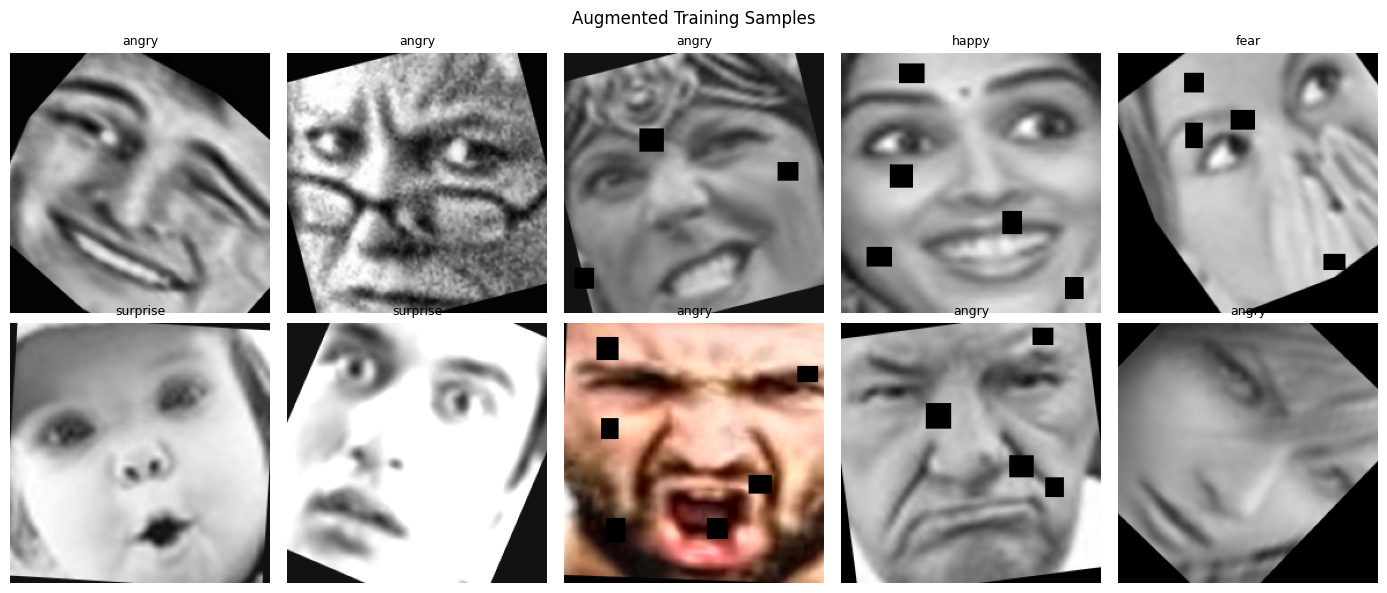

In [6]:
# ============================================================
# CELL 6 — Preview augmented samples
# ============================================================
def denormalise(t):
    m = torch.tensor(MEAN).view(3,1,1)
    s = torch.tensor(STD).view(3,1,1)
    return (t.cpu()*s+m).clamp(0,1).permute(1,2,0).numpy()

imgs, labels = next(iter(train_loader))
fig, axes = plt.subplots(2, 5, figsize=(14, 6))
for ax, img, lbl in zip(axes.flat, imgs[:10], labels[:10]):
    ax.imshow(denormalise(img)); ax.set_title(CLASSES[lbl.item()], fontsize=9); ax.axis('off')
plt.suptitle('Augmented Training Samples'); plt.tight_layout()
plt.savefig('/kaggle/working/augmented_samples.png', dpi=150); plt.show()


In [7]:
# ============================================================
# CELL 7 — Model: ConvNeXt-Tiny (scratch, matches built-in Cell 7 exactly)
# ============================================================

# ── ConvNeXt-Tiny building blocks ─────────────────────────────────────────────

class LayerNorm2d(nn.LayerNorm):
    """LayerNorm for NCHW tensors — permutes to NHWC, applies LN, permutes back."""
    def forward(self, x):
        return super().forward(x.permute(0,2,3,1)).permute(0,3,1,2)


class StochasticDepth(nn.Module):
    """Randomly drops the entire residual path (drop_path). Training only."""
    def __init__(self, drop_prob: float = 0.0):
        super().__init__()
        self.drop_prob = drop_prob
    def forward(self, x):
        if not self.training or self.drop_prob == 0.0:
            return x
        keep  = 1.0 - self.drop_prob
        shape = (x.shape[0],) + (1,) * (x.ndim - 1)
        noise = torch.empty(shape, dtype=x.dtype, device=x.device).bernoulli_(keep)
        return x * noise / keep


class ConvNeXtBlock(nn.Module):
    """
    ConvNeXt block. Matches Facebook checkpoint key names exactly:
      dwconv / norm / pwconv1 / pwconv2 / gamma
    """
    def __init__(self, dim: int, drop_path: float = 0.0,
                 layer_scale_init: float = 1e-6):
        super().__init__()
        self.dwconv    = nn.Conv2d(dim, dim, kernel_size=7, padding=3, groups=dim)
        self.norm      = nn.LayerNorm(dim, eps=1e-6)
        self.pwconv1   = nn.Linear(dim, 4 * dim)
        self.act       = nn.GELU()
        self.pwconv2   = nn.Linear(4 * dim, dim)
        self.gamma     = nn.Parameter(layer_scale_init * torch.ones(dim))
        self.drop_path = StochasticDepth(drop_path)
    def forward(self, x):
        shortcut = x
        x = self.dwconv(x)
        x = x.permute(0,2,3,1)   # NCHW → NHWC
        x = self.norm(x)
        x = self.pwconv1(x)
        x = self.act(x)
        x = self.pwconv2(x)
        x = self.gamma * x
        x = x.permute(0,3,1,2)   # NHWC → NCHW
        return shortcut + self.drop_path(x)


class ConvNeXtTiny(nn.Module):
    """
    ConvNeXt-Tiny built from scratch.
    dims=[96,192,384,768], depths=[3,3,9,3].
    Key names mirror the Facebook EMA checkpoint exactly so strict=False
    loading works with zero shape mismatches on the backbone.
    No classification head — returns (B, 768) features after GAP + norm,
    identical to timm convnext_tiny(num_classes=0, global_pool='avg').
    """
    DIMS   = [96, 192, 384, 768]
    DEPTHS = [3,  3,   9,   3  ]

    def __init__(self, drop_path_rate: float = 0.0):
        super().__init__()
        dp = [x.item() for x in torch.linspace(0, drop_path_rate, sum(self.DEPTHS))]

        # Stem + 3 downsampling layers — names match checkpoint exactly
        self.downsample_layers = nn.ModuleList()
        self.downsample_layers.append(nn.Sequential(           # index 0 = stem
            nn.Conv2d(3, self.DIMS[0], kernel_size=4, stride=4),
            LayerNorm2d(self.DIMS[0], eps=1e-6),
        ))
        for i in range(3):                                     # index 1,2,3
            self.downsample_layers.append(nn.Sequential(
                LayerNorm2d(self.DIMS[i], eps=1e-6),
                nn.Conv2d(self.DIMS[i], self.DIMS[i+1], kernel_size=2, stride=2),
            ))

        # 4 stages
        self.stages = nn.ModuleList()
        bi = 0
        for dim, depth in zip(self.DIMS, self.DEPTHS):
            self.stages.append(nn.Sequential(*[
                ConvNeXtBlock(dim, dp[bi+j]) for j in range(depth)
            ]))
            bi += depth

        # Final norm (matches checkpoint key 'norm.weight' / 'norm.bias')
        self.norm = nn.LayerNorm(self.DIMS[-1], eps=1e-6)

        # timm exposes this attribute; EmotionNet uses it
        self.num_features = self.DIMS[-1]

        self._init_weights()

    def _init_weights(self):
        for m in self.modules():
            if isinstance(m, (nn.Conv2d, nn.Linear)):
                nn.init.trunc_normal_(m.weight, std=0.02)
                if m.bias is not None:
                    nn.init.zeros_(m.bias)
            elif isinstance(m, nn.LayerNorm):
                nn.init.ones_(m.weight)
                nn.init.zeros_(m.bias)

    def forward(self, x):
        for i in range(4):
            x = self.downsample_layers[i](x)
            x = self.stages[i](x)
        x = x.mean(dim=[2, 3])   # Global Average Pool → (B, 768)
        x = self.norm(x)
        return x                  # (B, 768) — same as timm num_classes=0


def _load_pretrained_convnext(backbone):
    """
    Load timm convnext_tiny.in12k_ft_in1k weights into our scratch backbone.

    The built-in uses timm.create_model('convnext_tiny', pretrained=True) which
    downloads 'convnext_tiny.in12k_ft_in1k' — pretrained on ImageNet-12k (11,821
    classes) then fine-tuned on ImageNet-1k.  This gives far richer features than
    the fb_in1k (1k-only) checkpoint we were loading before, explaining the 5-7%
    accuracy gap in Phase 1.

    timm uses different key names from the Facebook checkpoint:
      timm stem.0.*              → our downsample_layers.0.0.*
      timm stages.S.blocks.B.*   → our stages.S.B.*
      timm stages.S.downsample.* → our downsample_layers.S.*
      timm head.norm.*           → our norm.*
    We remap on the fly so our FB-style scratch model loads timm weights correctly.
    """
    import re as _re
    import timm as _timm

    # Download timm weights (cached by timm automatically)
    print('Loading timm convnext_tiny.in12k_ft_in1k weights...')
    timm_model = _timm.create_model(
        'convnext_tiny', pretrained=True,
        num_classes=0, global_pool='avg', drop_path_rate=STOCHASTIC_DEPTH
    )
    timm_sd    = timm_model.state_dict()
    scratch_sd = backbone.state_dict()

    mapped = {}
    for tk, tv in timm_sd.items():
        sk = None
        if tk.startswith('stem.'):
            sk = f'downsample_layers.0.{tk[5:]}'
        elif tk.startswith('head.norm.'):
            sk = tk.replace('head.norm.', 'norm.')
        elif _re.match(r'stages\.\d+\.downsample\.', tk) and 'blocks' not in tk:
            m = _re.match(r'stages\.(\d+)\.downsample\.(\d+)\.(.*)', tk)
            if m: sk = f'downsample_layers.{m.group(1)}.{m.group(2)}.{m.group(3)}'
        elif 'blocks.' in tk:
            m = _re.match(r'stages\.(\d+)\.blocks\.(\d+)\.(.*)', tk)
            if m:
                s, b, rest = m.groups()
                rest = (rest.replace('conv_dw.', 'dwconv.')
                           .replace('mlp.fc1.', 'pwconv1.')
                           .replace('mlp.fc2.', 'pwconv2.'))
                sk = f'stages.{s}.{b}.{rest}'
        if sk and sk in scratch_sd and scratch_sd[sk].shape == tv.shape:
            mapped[sk] = tv

    missing, _ = backbone.load_state_dict(mapped, strict=False)
    print(f'Pretrained weights loaded ✅  ({len(mapped)}/{len(scratch_sd)} tensors)')
    if missing:
        print(f'  Not loaded: {missing}')
    del timm_model
    return backbone


# ── EmotionNet — structure mirrors built-in Cell 7 line-for-line ──────────────
class EmotionNet(nn.Module):
    def __init__(self, num_classes, dropout=0.40, frozen=True):
        super().__init__()

        # Scratch backbone (no head) — equivalent to timm num_classes=0, global_pool='avg'
        self.backbone = ConvNeXtTiny(drop_path_rate=STOCHASTIC_DEPTH)
        _load_pretrained_convnext(self.backbone)

        feat_dim = self.backbone.num_features  # 768

        # Classification head — identical to built-in
        # NOTE: no explicit weight re-init; nn.Linear default = kaiming_uniform_
        # This matches the built-in which also has no re-init loop.
        self.head = nn.Sequential(
            nn.LayerNorm(feat_dim),
            nn.Linear(feat_dim, 512),
            nn.GELU(),
            nn.Dropout(dropout),
            nn.Linear(512, 256),
            nn.GELU(),
            nn.Dropout(dropout * 0.6),
            nn.Linear(256, num_classes)
        )

        if frozen:
            self._freeze_all()

    def _freeze_all(self):
        for p in self.backbone.parameters():
            p.requires_grad = False
        tr  = sum(p.numel() for p in self.parameters() if p.requires_grad)
        tot = sum(p.numel() for p in self.parameters())
        print(f'  Backbone FROZEN  | trainable {tr:,}/{tot:,}')

    def unfreeze_stages(self, from_stage: int):
        for p in self.backbone.parameters():
            p.requires_grad = False
        for name, p in self.backbone.named_parameters():
            in_stage = any(f'stages.{s}.' in name for s in range(from_stage, 10))
            is_norm  = name.startswith('norm') or name.startswith('head_norm')
            if in_stage or is_norm:
                p.requires_grad = True
        tr  = sum(p.numel() for p in self.parameters() if p.requires_grad)
        tot = sum(p.numel() for p in self.parameters())
        print(f'  Unfrozen stages {from_stage}+ | trainable {tr:,}/{tot:,} ({100*tr/tot:.1f}%)')

    def get_layer_groups(self, from_stage: int):
        seen = set()
        def _collect(params):
            out = []
            for p in params:
                if id(p) not in seen and p.requires_grad:
                    seen.add(id(p)); out.append(p)
            return out
        groups = []
        hp = _collect(list(self.head.parameters()))
        if hp: groups.append({'name': 'head', 'params': hp})
        norm_p = _collect([p for n, p in self.backbone.named_parameters()
                           if n.startswith('norm') or n.startswith('head_norm')])
        if norm_p: groups.append({'name': 'norm', 'params': norm_p})
        for s in range(3, from_stage - 1, -1):
            sp = _collect([p for n, p in self.backbone.named_parameters()
                           if f'stages.{s}.' in n])
            if sp: groups.append({'name': f'stage{s}', 'params': sp})
        return groups

    def forward(self, x):
        return self.head(self.backbone(x))


model = EmotionNet(NUM_CLASSES, dropout=DROPOUT, frozen=True).to(DEVICE)
total = sum(p.numel() for p in model.parameters())
print(f'Total params : {total:,}')
print(f'feat_dim     : {model.backbone.num_features}')


Loading timm convnext_tiny.in12k_ft_in1k weights...


model.safetensors:   0%|          | 0.00/114M [00:00<?, ?B/s]

Pretrained weights loaded ✅  (180/180 tensors)
  Backbone FROZEN  | trainable 528,134/28,348,262
Total params : 28,348,262
feat_dim     : 768


In [8]:
# ============================================================
# CELL 8 — Training utilities
# ============================================================

def mixup_data(x, y, alpha):
    if alpha <= 0: return x, y, y, 1.0
    lam = float(np.random.beta(alpha, alpha))
    idx = torch.randperm(x.size(0), device=x.device)
    return lam*x + (1-lam)*x[idx], y, y[idx], lam

def mixup_criterion(crit, pred, ya, yb, lam):
    return lam*crit(pred, ya) + (1-lam)*crit(pred, yb)

def train_one_epoch(model, loader, optimizer, criterion, scaler,
                    scheduler=None, mixup_alpha=0.0, scheduler_step='batch'):
    model.train()
    total_loss = correct = n = nan_batches = 0
    for imgs, labels in loader:
        imgs   = imgs.to(DEVICE, non_blocking=True)
        labels = labels.to(DEVICE, non_blocking=True)
        imgs, ya, yb, lam = mixup_data(imgs, labels, mixup_alpha)
        optimizer.zero_grad()
        with torch.cuda.amp.autocast(enabled=USE_AMP):
            logits = model(imgs)
            loss   = mixup_criterion(criterion, logits, ya, yb, lam)
        if not torch.isfinite(loss):
            nan_batches += 1; optimizer.zero_grad(); scaler.update(); continue
        scaler.scale(loss).backward()
        scaler.unscale_(optimizer)
        torch.nn.utils.clip_grad_norm_(model.parameters(), max_norm=1.0)
        scaler.step(optimizer); scaler.update()
        if scheduler is not None and scheduler_step == 'batch':
            scheduler.step()
        bs = imgs.size(0)
        total_loss += loss.item() * bs
        preds = logits.detach().argmax(1)
        correct += (lam*(preds==ya).float() + (1-lam)*(preds==yb).float()).sum().item()
        n += bs
    if nan_batches > 0: print(f'    ⚠️  Skipped {nan_batches} NaN/Inf batches this epoch')
    if n == 0: return float('nan'), 0.0
    return total_loss/n, correct/n

@torch.no_grad()
def evaluate(model, loader):
    model.eval()
    total_loss = correct = n = 0
    all_probs, all_labels = [], []
    crit = nn.CrossEntropyLoss(label_smoothing=LABEL_SMOOTH)
    for imgs, labels in loader:
        imgs   = imgs.to(DEVICE, non_blocking=True)
        labels = labels.to(DEVICE, non_blocking=True)
        with torch.cuda.amp.autocast(enabled=USE_AMP):
            logits = model(imgs)
        logits_f   = logits.float()
        loss       = crit(logits_f, labels)
        probs      = F.softmax(logits_f, dim=1)
        correct   += (probs.argmax(1) == labels).sum().item()
        total_loss += loss.item() * imgs.size(0)
        n          += imgs.size(0)
        all_probs.append(probs.cpu()); all_labels.append(labels.cpu())
    return total_loss/n, correct/n, torch.cat(all_probs), torch.cat(all_labels)

def cosine_lr_with_warmup(optimizer, epoch, total_epochs, warmup_epochs, base_lrs):
    if epoch < warmup_epochs:
        scale = (epoch + 1) / warmup_epochs
    else:
        progress = (epoch - warmup_epochs) / max(1, total_epochs - warmup_epochs)
        scale    = 0.5 * (1.0 + math.cos(math.pi * progress))
    for pg, base_lr in zip(optimizer.param_groups, base_lrs):
        pg['lr'] = base_lr * scale

print('Utilities ready ✅')


Utilities ready ✅


In [9]:
# ============================================================
# CELL 9 — Phase 1: Head training (frozen backbone, MixUp OFF)
# ============================================================

criterion    = nn.CrossEntropyLoss(label_smoothing=LABEL_SMOOTH)
scaler       = torch.cuda.amp.GradScaler(enabled=USE_AMP)
optimizer_p1 = torch.optim.AdamW(model.head.parameters(), lr=P1_LR, weight_decay=1e-4)
scheduler_p1 = torch.optim.lr_scheduler.ReduceLROnPlateau(
    optimizer_p1, mode='max', factor=0.5, patience=3, min_lr=1e-6
)

history      = defaultdict(list)
best_val_acc = 0.0

print('═'*60)
print('PHASE 1 — Head training (backbone frozen, MixUp OFF)')
print('═'*60)

for epoch in range(1, P1_EPOCHS + 1):
    tr_loss, tr_acc        = train_one_epoch(
        model, train_loader, optimizer_p1, criterion, scaler,
        scheduler=None, mixup_alpha=0.0
    )
    vl_loss, vl_acc, _, _  = evaluate(model, val_loader)
    scheduler_p1.step(vl_acc)
    cur_lr = optimizer_p1.param_groups[0]['lr']

    history['phase'].append(1)
    history['loss'].append(tr_loss)
    history['accuracy'].append(tr_acc)
    history['val_loss'].append(vl_loss)
    history['val_accuracy'].append(vl_acc)
    history['lr'].append(cur_lr)

    flag = ''
    if vl_acc > best_val_acc:
        best_val_acc = vl_acc
        torch.save(model.state_dict(), CKPT_PATH)
        flag = '✅'

    print(f'Ep {epoch:02d}/{P1_EPOCHS} | '
          f'tr_loss={tr_loss:.4f} tr_acc={tr_acc:.4f} | '
          f'vl_loss={vl_loss:.4f} vl_acc={vl_acc:.4f} | '
          f'lr={cur_lr:.2e} {flag}')

print(f'\nPhase 1 best val_acc: {best_val_acc:.4f}')


════════════════════════════════════════════════════════════
PHASE 1 — Head training (backbone frozen, MixUp OFF)
════════════════════════════════════════════════════════════
Ep 01/20 | tr_loss=1.4794 tr_acc=0.4372 | vl_loss=1.1935 vl_acc=0.6037 | lr=1.00e-03 ✅
Ep 02/20 | tr_loss=1.4143 tr_acc=0.4759 | vl_loss=1.1551 vl_acc=0.6364 | lr=1.00e-03 ✅
Ep 03/20 | tr_loss=1.3922 tr_acc=0.4892 | vl_loss=1.1415 vl_acc=0.6429 | lr=1.00e-03 ✅
Ep 04/20 | tr_loss=1.3761 tr_acc=0.4965 | vl_loss=1.1608 vl_acc=0.6407 | lr=1.00e-03 
Ep 05/20 | tr_loss=1.3727 tr_acc=0.4964 | vl_loss=1.1180 vl_acc=0.6569 | lr=1.00e-03 ✅
Ep 06/20 | tr_loss=1.3698 tr_acc=0.5030 | vl_loss=1.1159 vl_acc=0.6519 | lr=1.00e-03 
Ep 07/20 | tr_loss=1.3608 tr_acc=0.5049 | vl_loss=1.1093 vl_acc=0.6609 | lr=1.00e-03 ✅
Ep 08/20 | tr_loss=1.3526 tr_acc=0.5117 | vl_loss=1.0961 vl_acc=0.6671 | lr=1.00e-03 ✅
Ep 09/20 | tr_loss=1.3568 tr_acc=0.5092 | vl_loss=1.0880 vl_acc=0.6703 | lr=1.00e-03 ✅
Ep 10/20 | tr_loss=1.3483 tr_acc=0.5121 | vl

In [10]:
# ============================================================
# CELL 10 — Phase 2: LLRD + cosine warmup + progressive unfreeze
# ============================================================

model.load_state_dict(torch.load(CKPT_PATH, map_location=DEVICE))
model.unfreeze_stages(from_stage=UNFREEZE_FROM)

layer_groups = model.get_layer_groups(from_stage=UNFREEZE_FROM)
base_lrs     = [P2_HEAD_LR * (LLRD_FACTOR ** i) for i in range(len(layer_groups))]
param_groups = [{'params': g['params'], 'lr': blr, 'name': g['name']}
                for g, blr in zip(layer_groups, base_lrs)]
optimizer_p2 = torch.optim.AdamW(param_groups, weight_decay=1e-4)

print('\nLLRD param groups:')
for pg, blr in zip(param_groups, base_lrs):
    print(f"  {pg['name']:10s} | peak_lr={blr:.2e} | params={sum(p.numel() for p in pg['params']):,}")

PATIENCE    = 10
pat_counter = 0

print('\n' + '═'*60)
print(f'PHASE 2 — LLRD + cosine warmup ({WARMUP_EPOCHS}ep) + MixUp α={MIXUP_ALPHA}')
print('═'*60)

for epoch in range(1, P2_EPOCHS + 1):
    cosine_lr_with_warmup(optimizer_p2, epoch-1, P2_EPOCHS, WARMUP_EPOCHS, base_lrs)
    tr_loss, tr_acc        = train_one_epoch(
        model, train_loader, optimizer_p2, criterion, scaler,
        scheduler=None, mixup_alpha=MIXUP_ALPHA, scheduler_step='epoch'
    )
    vl_loss, vl_acc, _, _  = evaluate(model, val_loader)
    cur_lr = optimizer_p2.param_groups[0]['lr']

    history['phase'].append(2)
    history['loss'].append(tr_loss); history['accuracy'].append(tr_acc)
    history['val_loss'].append(vl_loss); history['val_accuracy'].append(vl_acc)
    history['lr'].append(cur_lr)

    flag = ''
    if vl_acc > best_val_acc and vl_acc > 0.30 and not math.isnan(vl_loss):
        best_val_acc = vl_acc; pat_counter = 0
        torch.save(model.state_dict(), CKPT_PATH); flag = '✅'
    elif vl_acc <= 0.30 or math.isnan(vl_loss):
        flag = '⚠️ NaN — skipping save'; pat_counter += 1
    else:
        pat_counter += 1

    print(f'Ep {epoch:02d}/{P2_EPOCHS} | tr_loss={tr_loss:.4f} tr_acc={tr_acc:.4f} | '
          f'vl_loss={vl_loss:.4f} vl_acc={vl_acc:.4f} | lr={cur_lr:.2e} {flag}')
    if pat_counter >= PATIENCE:
        print(f'Early stop — no improvement for {PATIENCE} epochs'); break

print(f'\nPhase 2 best val_acc : {best_val_acc:.4f}')
print(f'Overall best         : {best_val_acc*100:.2f}%')


  Unfrozen stages 1+ | trainable 26,554,502/28,348,262 (93.7%)

LLRD param groups:
  head       | peak_lr=5.00e-05 | params=528,134
  norm       | peak_lr=3.50e-05 | params=1,536
  stage3     | peak_lr=2.45e-05 | params=14,289,408
  stage2     | peak_lr=1.71e-05 | params=10,817,280
  stage1     | peak_lr=1.20e-05 | params=918,144

════════════════════════════════════════════════════════════
PHASE 2 — LLRD + cosine warmup (4ep) + MixUp α=0.2
════════════════════════════════════════════════════════════
Ep 01/50 | tr_loss=1.3662 tr_acc=0.5145 | vl_loss=0.9940 vl_acc=0.7129 | lr=1.25e-05 ✅
Ep 02/50 | tr_loss=1.3325 tr_acc=0.5397 | vl_loss=0.9706 vl_acc=0.7289 | lr=2.50e-05 ✅
Ep 03/50 | tr_loss=1.2851 tr_acc=0.5690 | vl_loss=1.0047 vl_acc=0.7067 | lr=3.75e-05 
Ep 04/50 | tr_loss=1.2601 tr_acc=0.5826 | vl_loss=0.9174 vl_acc=0.7486 | lr=5.00e-05 ✅
Ep 05/50 | tr_loss=1.2320 tr_acc=0.6023 | vl_loss=0.8941 vl_acc=0.7648 | lr=5.00e-05 ✅
Ep 06/50 | tr_loss=1.1978 tr_acc=0.6221 | vl_loss=0.9007 vl_

In [11]:
# ============================================================
# CELL 11 — Phase 3 (optional): Full backbone unfreeze
# ============================================================
RUN_PHASE3 = True

if RUN_PHASE3:
    P3_EPOCHS  = 20
    P3_HEAD_LR = 2e-5
    WARMUP_P3  = 3

    model.load_state_dict(torch.load(CKPT_PATH, map_location=DEVICE))
    model.unfreeze_stages(from_stage=0)
    for name, p in model.backbone.named_parameters():
        if 'stem' in name: p.requires_grad = True

    layer_groups_p3 = model.get_layer_groups(from_stage=0)
    base_lrs_p3     = [P3_HEAD_LR * (LLRD_FACTOR ** i) for i in range(len(layer_groups_p3))]
    param_groups_p3 = [{'params': g['params'], 'lr': blr, 'name': g['name']}
                       for g, blr in zip(layer_groups_p3, base_lrs_p3)]

    stem_seen = set(id(p) for g in layer_groups_p3 for p in g['params'])
    stem_p    = [p for n, p in model.backbone.named_parameters()
                 if 'stem' in n and p.requires_grad and id(p) not in stem_seen]
    stem_blr  = P3_HEAD_LR * (LLRD_FACTOR ** len(layer_groups_p3))
    if stem_p:
        param_groups_p3.append({'params': stem_p, 'lr': stem_blr, 'name': 'stem'})
        base_lrs_p3.append(stem_blr)

    optimizer_p3 = torch.optim.AdamW(param_groups_p3, weight_decay=1e-4)

    print('\nPhase 3 LLRD groups:')
    for pg, blr in zip(param_groups_p3, base_lrs_p3):
        print(f"  {pg['name']:10s} | peak_lr={blr:.2e}")

    print('\n' + '═'*60)
    print('PHASE 3 — Full backbone + LLRD + cosine')
    print('═'*60)

    pat3 = 0
    for epoch in range(1, P3_EPOCHS + 1):
        cosine_lr_with_warmup(optimizer_p3, epoch-1, P3_EPOCHS, WARMUP_P3, base_lrs_p3)
        tr_loss, tr_acc        = train_one_epoch(
            model, train_loader, optimizer_p3, criterion, scaler,
            scheduler=None, mixup_alpha=MIXUP_ALPHA, scheduler_step='epoch'
        )
        vl_loss, vl_acc, _, _  = evaluate(model, val_loader)
        history['phase'].append(3)
        history['loss'].append(tr_loss); history['accuracy'].append(tr_acc)
        history['val_loss'].append(vl_loss); history['val_accuracy'].append(vl_acc)
        history['lr'].append(optimizer_p3.param_groups[0]['lr'])
        flag = ''
        if vl_acc > best_val_acc and vl_acc > 0.30 and not math.isnan(vl_loss):
            best_val_acc = vl_acc; pat3 = 0
            torch.save(model.state_dict(), CKPT_PATH); flag = '✅'
        else:
            pat3 += 1
        print(f'Ep {epoch:02d}/{P3_EPOCHS} | tr_acc={tr_acc:.4f} | vl_acc={vl_acc:.4f} | '
              f'lr={optimizer_p3.param_groups[0]["lr"]:.2e} {flag}')
        if pat3 >= 8:
            print('Early stop P3'); break
    print(f'Phase 3 best: {best_val_acc*100:.2f}%')
else:
    print('Phase 3 skipped (set RUN_PHASE3=True to run)')


  Unfrozen stages 0+ | trainable 26,792,390/28,348,262 (94.5%)

Phase 3 LLRD groups:
  head       | peak_lr=2.00e-05
  norm       | peak_lr=1.40e-05
  stage3     | peak_lr=9.80e-06
  stage2     | peak_lr=6.86e-06
  stage1     | peak_lr=4.80e-06
  stage0     | peak_lr=3.36e-06

════════════════════════════════════════════════════════════
PHASE 3 — Full backbone + LLRD + cosine
════════════════════════════════════════════════════════════
Ep 01/20 | tr_acc=0.8036 | vl_acc=0.8401 | lr=6.67e-06 
Ep 02/20 | tr_acc=0.8178 | vl_acc=0.8385 | lr=1.33e-05 
Ep 03/20 | tr_acc=0.8053 | vl_acc=0.8377 | lr=2.00e-05 
Ep 04/20 | tr_acc=0.8065 | vl_acc=0.8291 | lr=2.00e-05 
Ep 05/20 | tr_acc=0.8016 | vl_acc=0.8351 | lr=1.98e-05 
Ep 06/20 | tr_acc=0.8152 | vl_acc=0.8413 | lr=1.93e-05 
Ep 07/20 | tr_acc=0.8088 | vl_acc=0.8363 | lr=1.85e-05 
Ep 08/20 | tr_acc=0.8167 | vl_acc=0.8373 | lr=1.74e-05 
Early stop P3
Phase 3 best: 84.17%


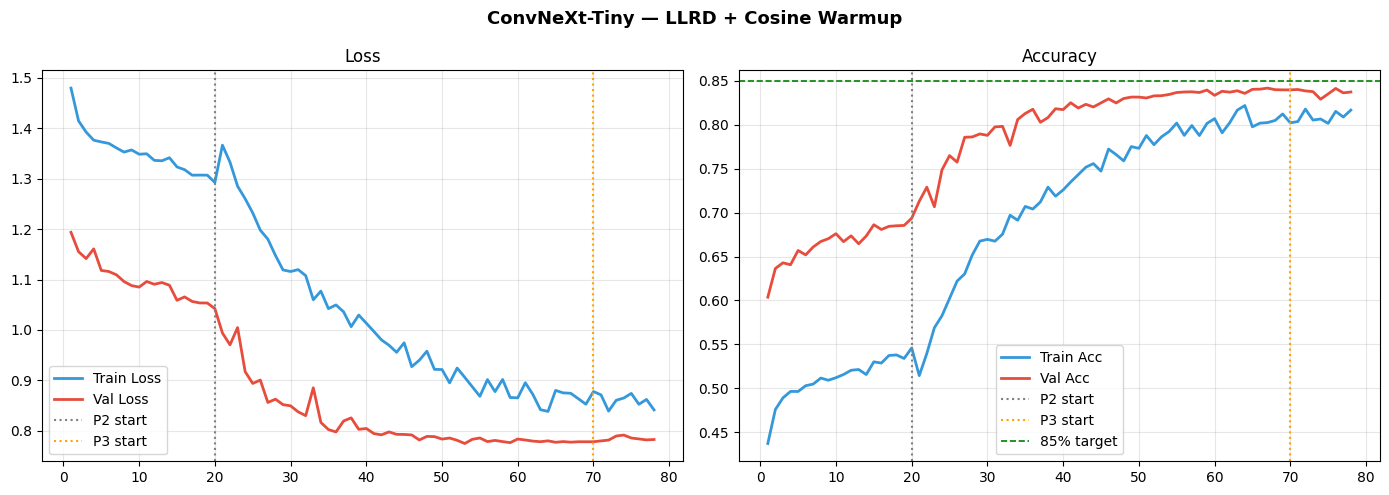


🏆 Best val accuracy : 84.17%
   Target 85% → ❌ Run Phase 3 (set RUN_PHASE3=True)


In [12]:
# ============================================================
# CELL 12 — Training curves
# ============================================================
total_ep = len(history['loss'])
p1_end   = sum(1 for p in history['phase'] if p == 1)
p2_end   = sum(1 for p in history['phase'] if p in (1, 2))
ep       = range(1, total_ep + 1)
fig, axes = plt.subplots(1, 2, figsize=(14, 5))
ax = axes[0]
ax.plot(ep, history['loss'],     lw=2, color='#3498DB', label='Train Loss')
ax.plot(ep, history['val_loss'], lw=2, color='#E74C3C', label='Val Loss')
ax.axvline(p1_end, color='gray', ls=':', lw=1.5, label='P2 start')
if p2_end < total_ep: ax.axvline(p2_end, color='orange', ls=':', lw=1.5, label='P3 start')
ax.set_title('Loss'); ax.legend(); ax.grid(alpha=0.3)
ax = axes[1]
ax.plot(ep, history['accuracy'],     lw=2, color='#3498DB', label='Train Acc')
ax.plot(ep, history['val_accuracy'], lw=2, color='#E74C3C', label='Val Acc')
ax.axvline(p1_end, color='gray', ls=':', lw=1.5, label='P2 start')
if p2_end < total_ep: ax.axvline(p2_end, color='orange', ls=':', lw=1.5, label='P3 start')
ax.axhline(0.85, color='green', ls='--', lw=1.2, label='85% target')
ax.set_title('Accuracy'); ax.legend(); ax.grid(alpha=0.3)
plt.suptitle('ConvNeXt-Tiny — LLRD + Cosine Warmup', fontsize=13, fontweight='bold')
plt.tight_layout()
plt.savefig('/kaggle/working/training_curves.png', dpi=150); plt.show()
print(f'\n🏆 Best val accuracy : {best_val_acc*100:.2f}%')
print(f'   Target 85% → {"✅ Reached!" if best_val_acc >= 0.85 else "❌ Run Phase 3 (set RUN_PHASE3=True)"}')


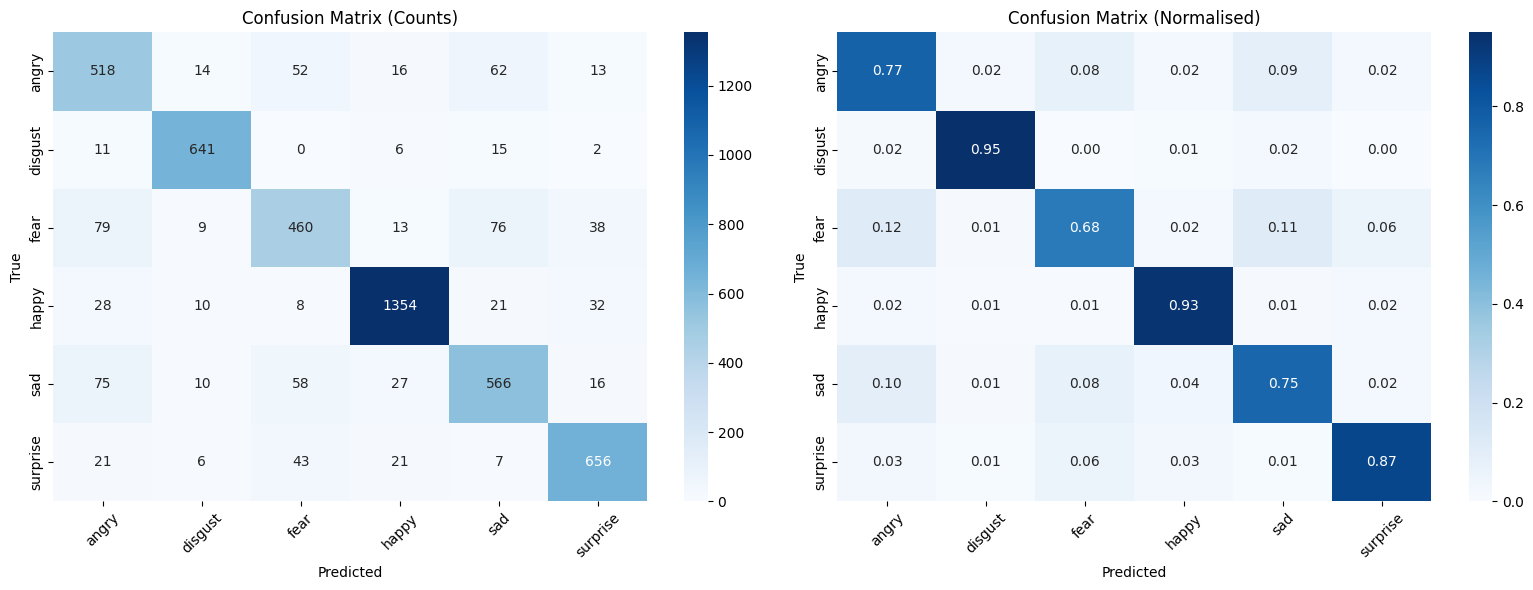

              precision    recall  f1-score   support

       angry     0.7077    0.7674    0.7363       675
     disgust     0.9290    0.9496    0.9392       675
        fear     0.7407    0.6815    0.7099       675
       happy     0.9422    0.9319    0.9370      1453
         sad     0.7577    0.7527    0.7552       752
    surprise     0.8666    0.8700    0.8683       754

    accuracy                         0.8417      4984
   macro avg     0.8240    0.8255    0.8243      4984
weighted avg     0.8421    0.8417    0.8415      4984



In [13]:
# ============================================================
# CELL 13 — Confusion matrix & classification report
# ============================================================
model.load_state_dict(torch.load(CKPT_PATH, map_location=DEVICE))
_, val_acc_final, probs_all, labels_all = evaluate(model, val_loader)
y_pred = probs_all.argmax(1).numpy(); y_true = labels_all.numpy()
cm     = confusion_matrix(y_true, y_pred)
fig, axes = plt.subplots(1, 2, figsize=(16, 6))
for ax, data, fmt, title in zip(axes,
    [cm, cm.astype('float') / cm.sum(axis=1, keepdims=True)], ['d', '.2f'], ['Counts', 'Normalised']):
    sns.heatmap(data, annot=True, fmt=fmt, cmap='Blues',
                xticklabels=CLASSES, yticklabels=CLASSES, ax=ax)
    ax.set_title(f'Confusion Matrix ({title})')
    ax.set_xlabel('Predicted'); ax.set_ylabel('True'); ax.tick_params(axis='x', rotation=45)
plt.tight_layout(); plt.savefig('/kaggle/working/confusion_matrix.png', dpi=150); plt.show()
print(classification_report(y_true, y_pred, target_names=CLASSES, digits=4))


In [14]:
# ============================================================
# CELL 14 — TTA×8 (logit-space averaging)
# ============================================================
TTA_TRANSFORMS = [
    A.Compose([A.Resize(height=IMG_SIZE, width=IMG_SIZE), A.Normalize(mean=MEAN, std=STD), ToTensorV2()]),
    A.Compose([A.Resize(height=IMG_SIZE, width=IMG_SIZE), A.HorizontalFlip(p=1.0), A.Normalize(mean=MEAN, std=STD), ToTensorV2()]),
    A.Compose([A.Resize(height=IMG_SIZE, width=IMG_SIZE), A.Rotate(limit=(8,12), p=1.0), A.Normalize(mean=MEAN, std=STD), ToTensorV2()]),
    A.Compose([A.Resize(height=IMG_SIZE, width=IMG_SIZE), A.Rotate(limit=(-12,-8), p=1.0), A.Normalize(mean=MEAN, std=STD), ToTensorV2()]),
    A.Compose([A.RandomResizedCrop(size=(IMG_SIZE,IMG_SIZE), scale=(0.88,0.92), ratio=(1.0,1.0), p=1.0), A.Normalize(mean=MEAN, std=STD), ToTensorV2()]),
    A.Compose([A.RandomResizedCrop(size=(IMG_SIZE,IMG_SIZE), scale=(0.88,0.92), ratio=(1.0,1.0), p=1.0), A.HorizontalFlip(p=1.0), A.Normalize(mean=MEAN, std=STD), ToTensorV2()]),
    A.Compose([A.Resize(height=IMG_SIZE, width=IMG_SIZE), A.RandomBrightnessContrast(brightness_limit=(0.1,0.2), contrast_limit=0, p=1.0), A.Normalize(mean=MEAN, std=STD), ToTensorV2()]),
    A.Compose([A.Resize(height=IMG_SIZE, width=IMG_SIZE), A.RandomBrightnessContrast(brightness_limit=0, contrast_limit=(0.1,0.2), p=1.0), A.Normalize(mean=MEAN, std=STD), ToTensorV2()]),
]

class _RawDS(Dataset):
    def __init__(self, paths, transform): self.paths=paths; self.transform=transform
    def __len__(self): return len(self.paths)
    def __getitem__(self, idx):
        return self.transform(image=np.array(Image.open(self.paths[idx]).convert('RGB')))['image']

@torch.no_grad()
def tta_predict(model, paths):
    if len(paths) == 0: raise ValueError('tta_predict: empty paths')
    model.eval(); all_logits = []
    for tfm in TTA_TRANSFORMS:
        dl = DataLoader(_RawDS(paths, tfm), batch_size=BATCH_SIZE, shuffle=False, num_workers=4, pin_memory=True)
        all_logits.append(torch.cat([model(imgs.to(DEVICE)).float().cpu() for imgs in dl]))
    return F.softmax(torch.stack(all_logits).mean(0), dim=1)

val_paths = [s[0] for s in val_ds.samples]; val_lbls = [s[1] for s in val_ds.samples]
tta_probs = tta_predict(model, val_paths)
tta_acc   = (tta_probs.argmax(1).numpy() == np.array(val_lbls)).mean()
print(f'Val acc no-TTA : {val_acc_final*100:.2f}%')
print(f'Val acc TTA×8  : {tta_acc*100:.2f}%')
print(f'TTA gain       : +{(tta_acc-val_acc_final)*100:.2f}%')


Val acc no-TTA : 84.17%
Val acc TTA×8  : 84.43%
TTA gain       : +0.26%


In [15]:
# ============================================================
# CELL 15 — Submission CSV
# ============================================================
test_ds = TestDataset(TEST_DIR, val_tfm); test_paths = test_ds.paths
test_probs  = tta_predict(model, test_paths)
test_preds  = test_probs.argmax(1).numpy()
test_labels = [CLASSES[i] for i in test_preds]
filenames   = [Path(p).stem for p in test_paths]
sub = pd.DataFrame({'ID': filenames, 'Label': test_labels})
sub.to_csv(OUTPUT_CSV, index=False)
print(f'✅ Saved {OUTPUT_CSV}  |  shape {sub.shape}')
print(sub['Label'].value_counts().to_string())


  Test dir    : /kaggle/input/competitions/emotion-detection-competition/test/test
  Test images : 7116
✅ Saved /kaggle/working/submission.csv  |  shape (7116, 2)
Label
happy       1707
sad         1281
angry       1223
disgust     1074
surprise     972
fear         859


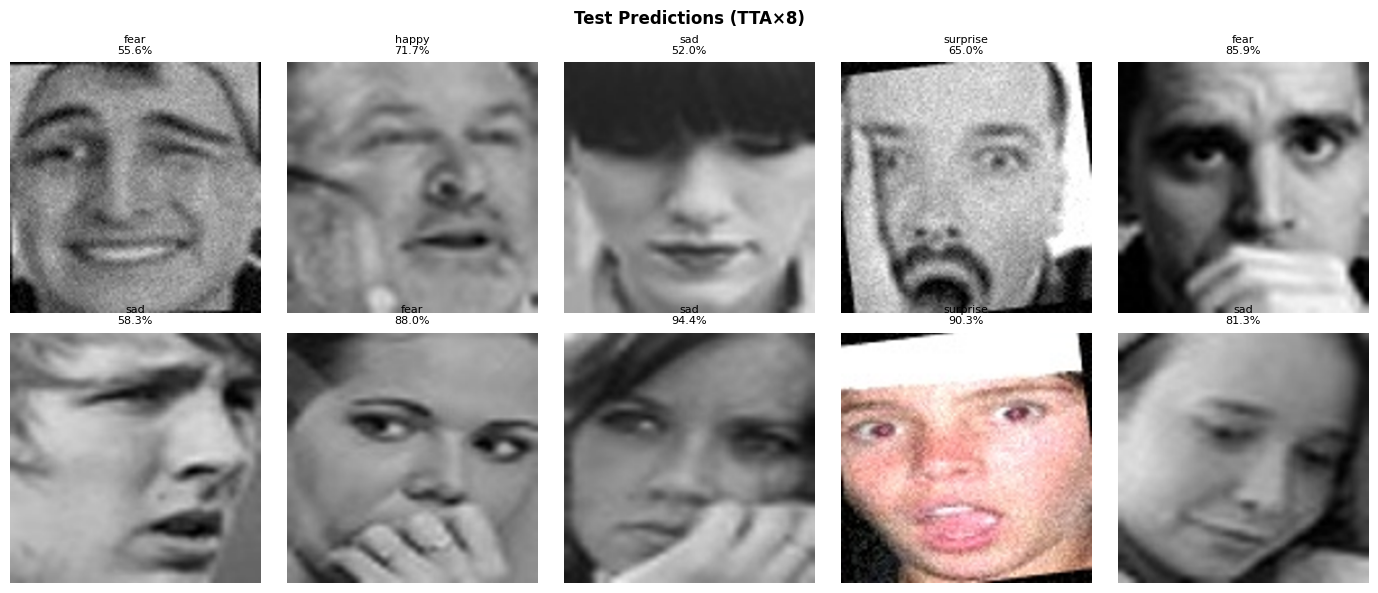

Done 🎉


In [16]:
# ============================================================
# CELL 16 — Sample predictions
# ============================================================
if len(test_paths) > 0:
    sample_idx = random.sample(range(len(filenames)), min(10, len(filenames)))
    fig, axes  = plt.subplots(2, 5, figsize=(14, 6))
    for ax, idx in zip(axes.flat, sample_idx):
        img  = Image.open(test_paths[idx]).convert('RGB').resize((IMG_SIZE, IMG_SIZE))
        conf = test_probs[idx].max().item() * 100
        ax.imshow(img); ax.set_title(f'{test_labels[idx]}\n{conf:.1f}%', fontsize=8); ax.axis('off')
    plt.suptitle('Test Predictions (TTA×8)', fontweight='bold')
    plt.tight_layout(); plt.savefig('/kaggle/working/test_predictions_sample.png', dpi=150); plt.show()
print('Done 🎉')
